# Chapter 1: Describing and Understanding Data


In this notebook, we use R to explore the main ideas from Chapter 1.

We will work with simple examples to understand:

- measures of center
- measures of spread
- outliers
- skewness and kurtosis
- relationships between variables


## Coffee Shop Daily Sales Data

In [2]:
sales <- c(120, 125, 128, 130, 122, 127,
           129, 131, 126, 124, 123, 135)

sales

[1] 120 125 128 130 122 127 129 131 126 124 123 135

## Mean

In [3]:
mean_sales <- mean(sales)

cat("Mean daily sales:", round(mean_sales, 2), "\n")

Mean daily sales: 126.67 


## Median

In [4]:
median_sales <- median(sales)

cat("Median daily sales:", median_sales, "\n")

Median daily sales: 126.5 


## Effect of an Outlier

In [5]:
sales_outlier <- c(120, 125, 128, 130, 122, 127,
                   129, 131, 126, 124, 123, 200)

mean_outlier <- mean(sales_outlier)
median_outlier <- median(sales_outlier)

cat("Mean with outlier:", round(mean_outlier, 2), "\n")
cat("Median with outlier:", median_outlier, "\n")

Mean with outlier: 132.08 
Median with outlier: 126.5 


## Visual Comparison

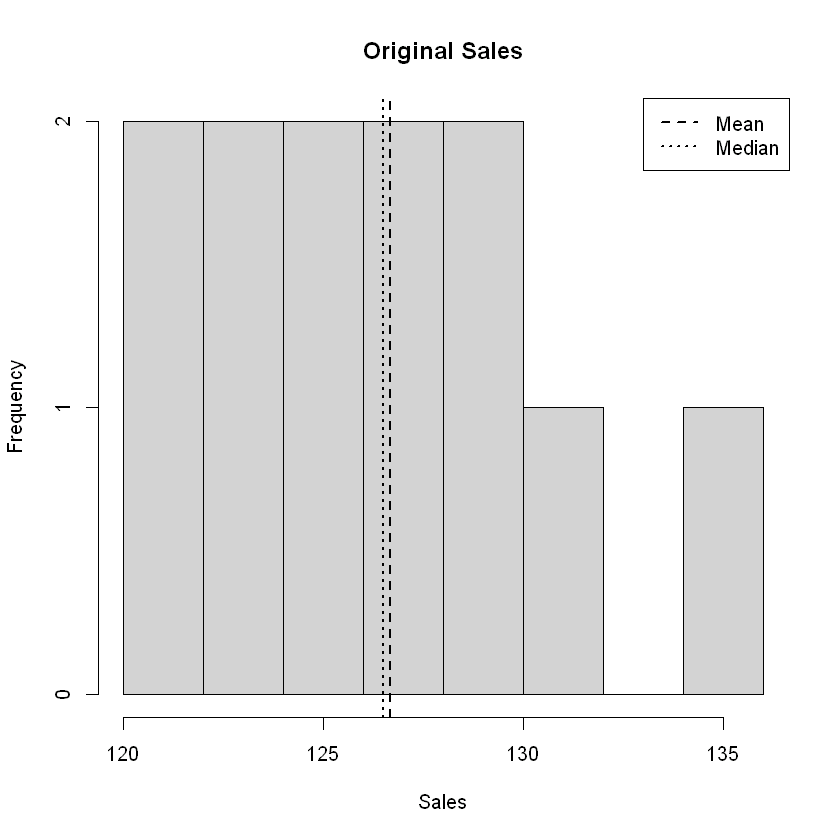

In [6]:
# Original sales data

hist(sales, breaks = 6, main = "Original Sales", xlab = "Sales")

abline(v = mean(sales), lty = 2, lwd = 2)
abline(v = median(sales), lty = 3, lwd = 2)

legend("topright",
       legend = c("Mean", "Median"),
       lty = c(2, 3),
       lwd = 2)

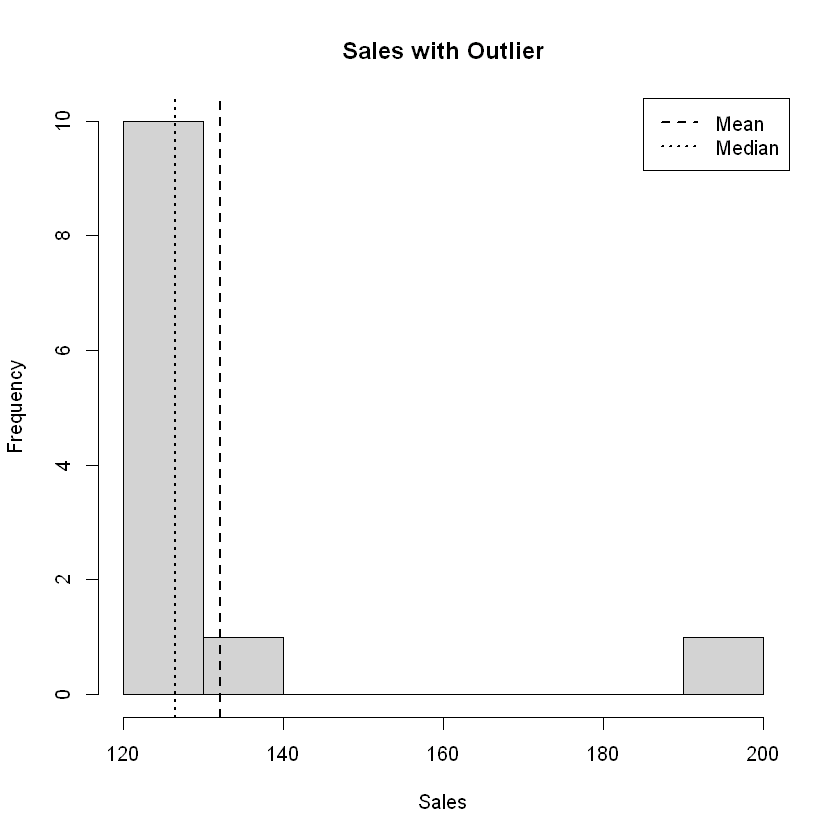

In [7]:
# Sales data with an outlier

hist(sales_outlier, breaks = 6, main = "Sales with Outlier", xlab = "Sales")

abline(v = mean(sales_outlier), lty = 2, lwd = 2)
abline(v = median(sales_outlier), lty = 3, lwd = 2)

legend("topright",
       legend = c("Mean", "Median"),
       lty = c(2, 3),
       lwd = 2)

## Weighted Mean

In [8]:
# Scores earned in each course component

scores <- c(80, 70, 90)

# Contribution of each component to the final grade
# Assignments = 40%
# Midterm = 25%
# Final Exam = 35%

weights <- c(0.40, 0.25, 0.35)

# Calculate the weighted mean

weighted_mean <- weighted.mean(scores, weights)

cat("Weighted mean:", weighted_mean, "\n")

Weighted mean: 81 


## Quartiles

In [9]:
# Returning to the coffee shop sales example

q1 <- quantile(sales, 0.25)
q2 <- quantile(sales, 0.50)
q3 <- quantile(sales, 0.75)

cat("Q1:", q1, "\n")
cat("Q2 (Median):", q2, "\n")
cat("Q3:", q3, "\n")

Q1: 123.75 
Q2 (Median): 126.5 
Q3: 129.25 


## Interquartile Range (IQR)

In [10]:
iqr <- q3 - q1

cat("IQR:", iqr, "\n")

IQR: 5.5 


## Detecting Outliers

In [11]:
lower_bound <- q1 - 1.5 * iqr
upper_bound <- q3 + 1.5 * iqr

cat("Lower boundary:", lower_bound, "\n")
cat("Upper boundary:", upper_bound, "\n")

outliers <- c()

for (value in sales_outlier) {
  if (value < lower_bound || value > upper_bound) {
    outliers <- c(outliers, value)
  }
}

cat("Outliers:", outliers, "\n")

Lower boundary: 115.5 
Upper boundary: 137.5 
Outliers: 200 


## Boxplot

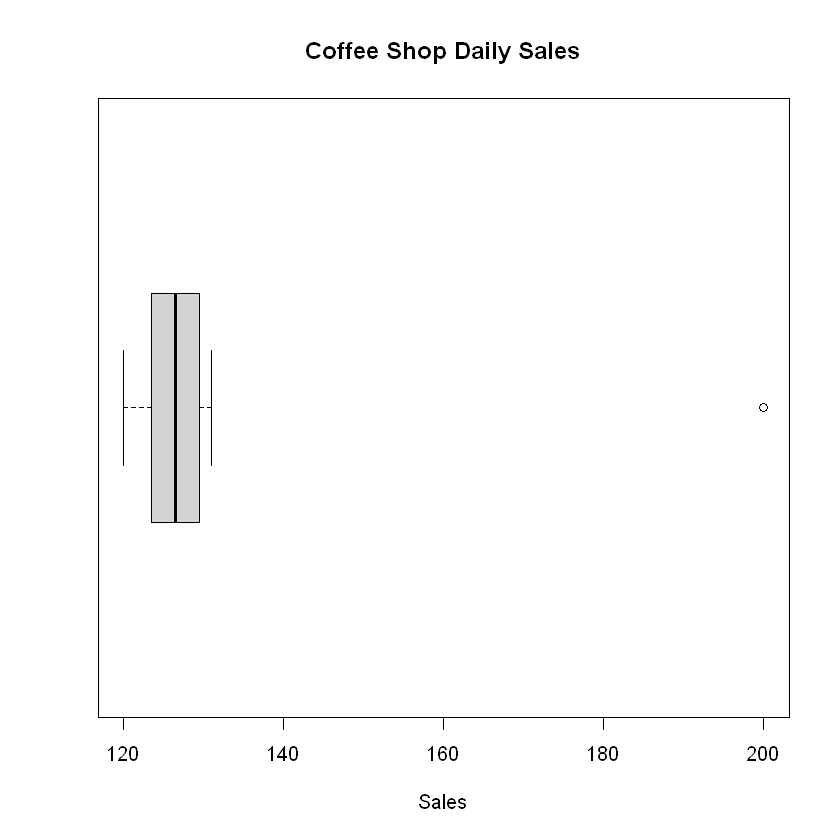

In [12]:
boxplot(sales_outlier,
        horizontal = TRUE,
        main = "Coffee Shop Daily Sales",
        xlab = "Sales")

## Range

In [13]:
data_range <- max(sales) - min(sales)

cat("Range:", data_range, "\n")

Range: 15 


## Variance and Standard Deviation

In [14]:
# R uses sample variance and sample standard deviation by default.
# To match the Python notebook, we calculate population variance and population standard deviation.

variance <- mean((sales - mean(sales))^2)
std_dev <- sqrt(variance)

cat("Variance:", round(variance, 2), "\n")
cat("Standard deviation:", round(std_dev, 2), "\n")

Variance: 16.39 
Standard deviation: 4.05 


## Skewness and Kurtosis

In [15]:
# We define simple helper functions for skewness and kurtosis.
# These are population-style versions, similar to the intuition used in the Python notebook.

skewness <- function(x) {
  mean((x - mean(x))^3) / sd(x)^3
}

kurtosis_value <- function(x) {
  mean((x - mean(x))^4) / sd(x)^4 - 3
}

In [16]:
sales_skewness <- skewness(sales)
sales_outlier_skewness <- skewness(sales_outlier)

cat("Skewness (original):", round(sales_skewness, 2), "\n")
cat("Skewness (with outlier):", round(sales_outlier_skewness, 2), "\n")

Skewness (original): 0.27 
Skewness (with outlier): 2.53 


In [17]:
sales_kurtosis <- kurtosis_value(sales)
sales_outlier_kurtosis <- kurtosis_value(sales_outlier)

cat("Kurtosis (original):", round(sales_kurtosis, 2), "\n")
cat("Kurtosis (with outlier):", round(sales_outlier_kurtosis, 2), "\n")

Kurtosis (original): -0.91 
Kurtosis (with outlier): 5.1 


## Study Hours and Exam Scores

In [18]:
study_hours <- c(1, 2, 3, 4, 5, 6, 7, 8)

exam_scores <- c(52, 55, 61, 65, 72, 78, 85, 90)

## Scatterplot

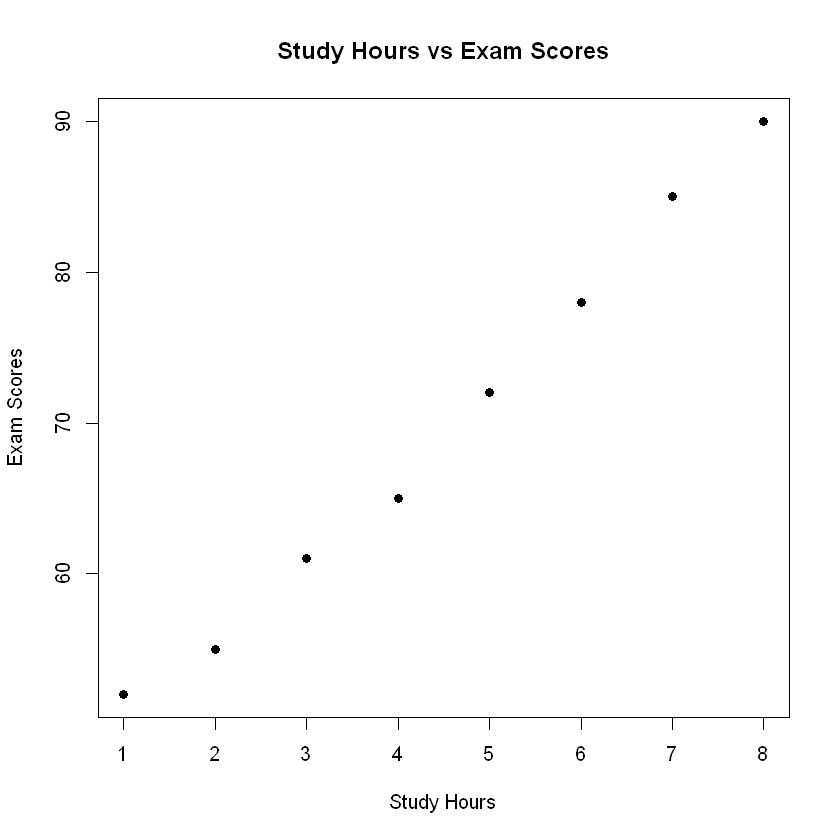

In [19]:
plot(study_hours, exam_scores,
     main = "Study Hours vs Exam Scores",
     xlab = "Study Hours",
     ylab = "Exam Scores",
     pch = 19)

## Covariance

In [20]:
cov_matrix <- cov(cbind(study_hours, exam_scores))

print(cov_matrix)

            study_hours exam_scores
study_hours     6.00000    33.85714
exam_scores    33.85714   192.50000


## Correlation

In [21]:
correlation <- cor(cbind(study_hours, exam_scores))

print(correlation)

            study_hours exam_scores
study_hours   1.0000000   0.9962293
exam_scores   0.9962293   1.0000000


## Anscombe’s Quartet

In [22]:
# Anscombe's Quartet is built into R as the dataset `anscombe`.

head(anscombe)

,x1,x2,x3,x4,y1,y2,y3,y4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,10,10,10,8,8.04,9.14,7.46,6.58
2,8,8,8,8,6.95,8.14,6.77,5.76
3,13,13,13,8,7.58,8.74,12.74,7.71
4,9,9,9,8,8.81,8.77,7.11,8.84
5,11,11,11,8,8.33,9.26,7.81,8.47
6,14,14,14,8,9.96,8.10,8.84,7.04


In [23]:
# Convert the built-in R version into a long format similar to the Python notebook.

anscombe_long <- data.frame(
  dataset = rep(c("I", "II", "III", "IV"), each = nrow(anscombe)),
  x = c(anscombe$x1, anscombe$x2, anscombe$x3, anscombe$x4),
  y = c(anscombe$y1, anscombe$y2, anscombe$y3, anscombe$y4)
)

head(anscombe_long)

,dataset,x,y
,<chr>,<dbl>,<dbl>
1,I,10,8.04
2,I,8,6.95
3,I,13,7.58
4,I,9,8.81
5,I,11,8.33
6,I,14,9.96


In [24]:
# Calculate the mean and standard deviation
# for each dataset in Anscombe's Quartet.

aggregate(cbind(x, y) ~ dataset,
          data = anscombe_long,
          FUN = function(z) c(mean = mean(z), sd = sd(z)))

dataset,x,y
<chr>,"<dbl[,2]>","<dbl[,2]>"
I,"9, 3.316625","7.500909, 2.031568"
II,"9, 3.316625","7.500909, 2.031657"
III,"9, 3.316625","7.500000, 2.030424"
IV,"9, 3.316625","7.500909, 2.030579"


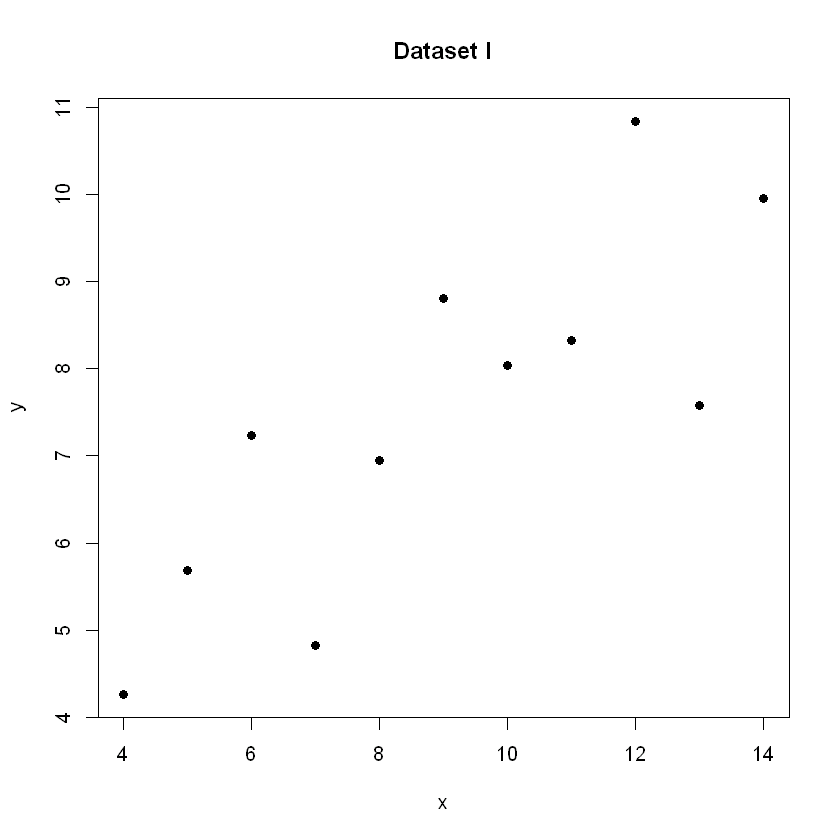

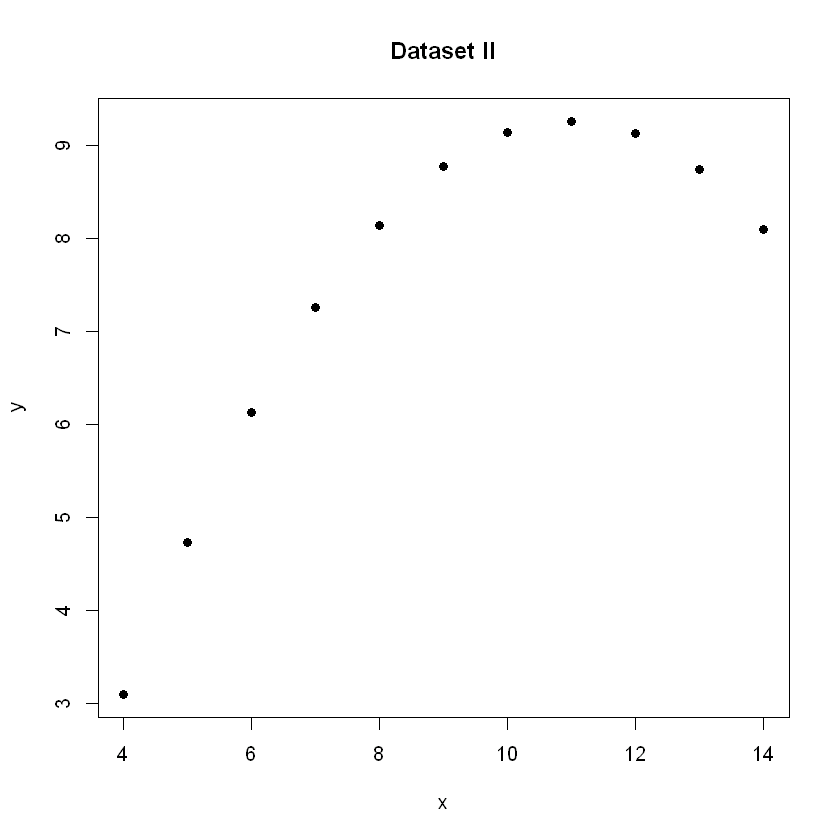

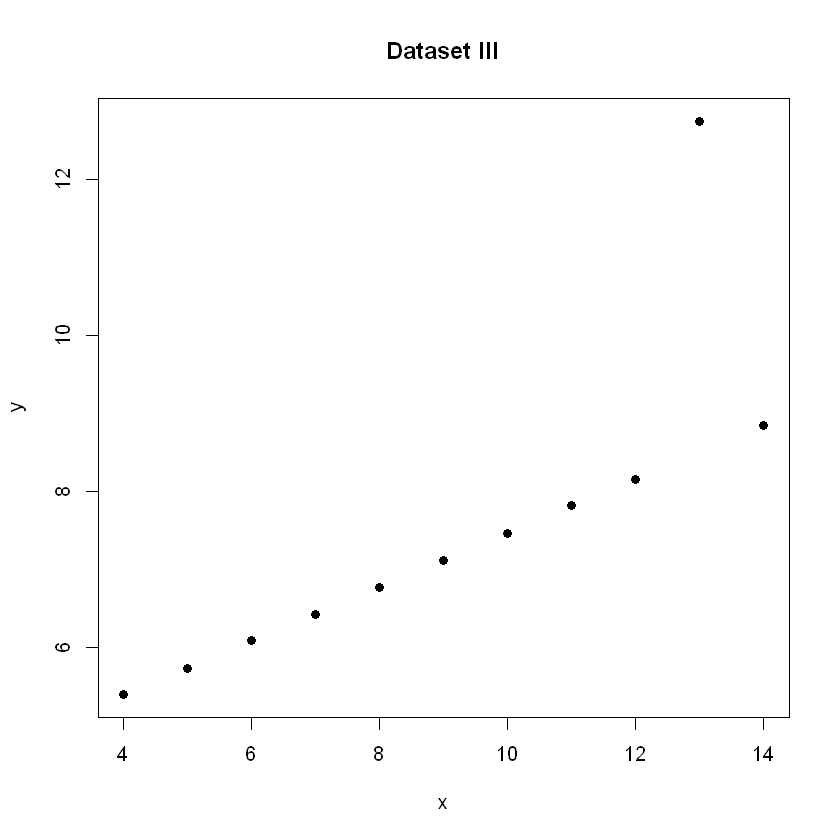

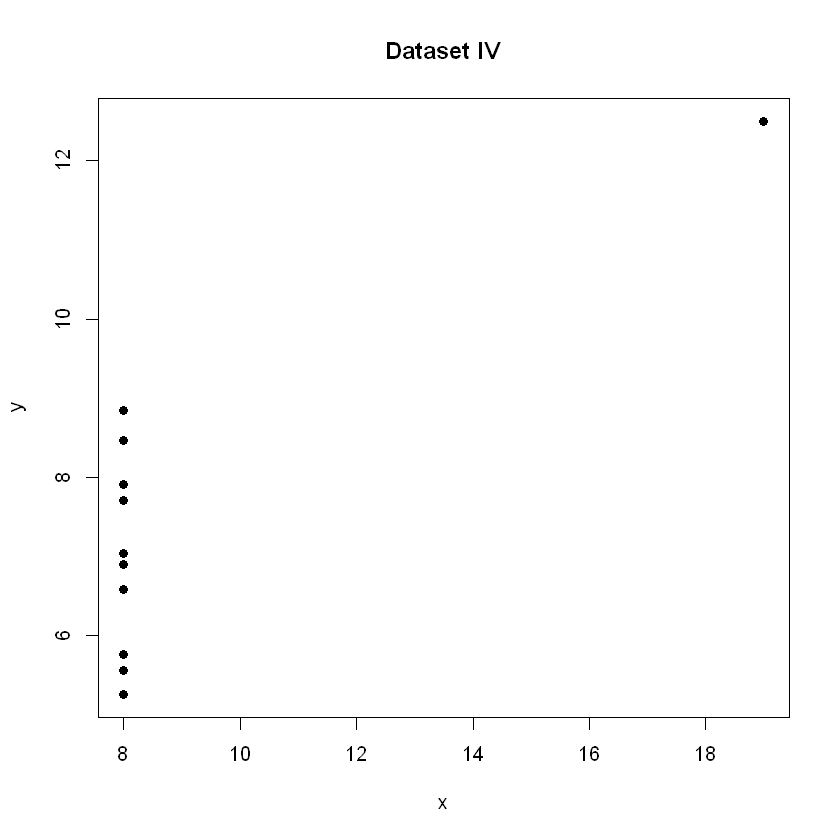

In [25]:
# Despite having nearly identical summary statistics,
# the four datasets behave very differently when visualized.

# Dataset I

dataset_1 <- subset(anscombe_long, dataset == "I")

plot(dataset_1$x, dataset_1$y,
     main = "Dataset I",
     xlab = "x",
     ylab = "y",
     pch = 19)

# Dataset II

dataset_2 <- subset(anscombe_long, dataset == "II")

plot(dataset_2$x, dataset_2$y,
     main = "Dataset II",
     xlab = "x",
     ylab = "y",
     pch = 19)

# Dataset III

dataset_3 <- subset(anscombe_long, dataset == "III")

plot(dataset_3$x, dataset_3$y,
     main = "Dataset III",
     xlab = "x",
     ylab = "y",
     pch = 19)

# Dataset IV

dataset_4 <- subset(anscombe_long, dataset == "IV")

plot(dataset_4$x, dataset_4$y,
     main = "Dataset IV",
     xlab = "x",
     ylab = "y",
     pch = 19)